### Regresión linea y visualización


regresion lineal:modelo matematico para representar relacion entre variables predictoras y var objetivo por medio de una recta
metricas de evaluacion r^2 , MSE y MAE

In [2]:
import pandas as pd 
import numpy as np 
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns



In [38]:
df=sns.load_dataset('tips')#dataset de seaborn
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [39]:
X=df['total_bill']
y=df['tip']
print(X)
print("----------------")
print(y)
print("----------------")



0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64
----------------
0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64
----------------


In [40]:
X_cons=sm.add_constant(X)#agruela una constante a la data X
print(X_cons)

     const  total_bill
0      1.0       16.99
1      1.0       10.34
2      1.0       21.01
3      1.0       23.68
4      1.0       24.59
..     ...         ...
239    1.0       29.03
240    1.0       27.18
241    1.0       22.67
242    1.0       17.82
243    1.0       18.78

[244 rows x 2 columns]


In [41]:
#modelo de regresion lineal basado en OLS (minimos cuadrados ordinario)
modelo=sm.OLS(y,X_cons).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           6.69e-34
Time:                        16:54:40   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

y=b_1X+b_0 + error
y=0.1050*X+0.9203 + error

R-squared:0.457 grado de ajuste (valor 0-1)

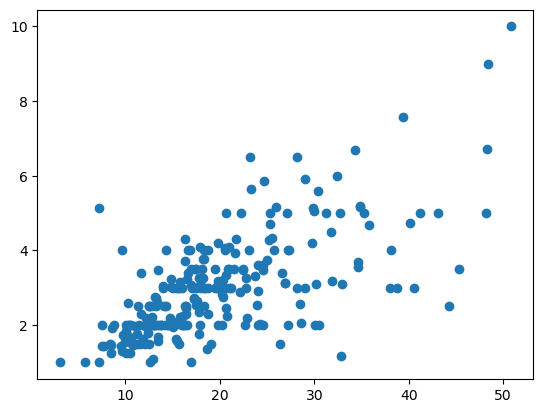

In [42]:
#graficar
plt.scatter(df['total_bill'],df['tip'])#permite nube de puntos con scatter

(0.0, 55.0)

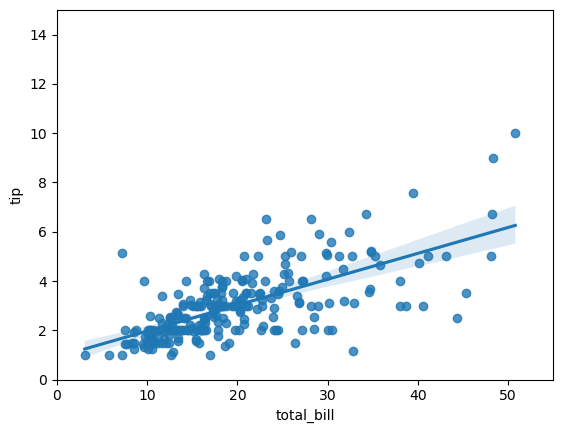

In [43]:
sns.regplot(x='total_bill',y='tip',data=df)# con seaborn y su funcion regplot podemos hacer el scatter con la funcion lineal
plt.ylim(0,15)
plt.xlim(0,55)  

In [44]:
#MAE (error absoluto medio)
mae=np.mean(np.abs(modelo.resid))
mae

0.7458253894586339

In [45]:
#MSE (Mean squeared Error) Error cuadratico medio
mse=np.mean(modelo.resid**2)
mse

1.036019442011377

In [46]:
#RMSE (raiz del error cuadratico medio)
rmse=np.sqrt(mse)
rmse

1.0178504025697377

In [47]:
nueva_lista=[1,50]
nueva_lista

[1, 50]

In [48]:
#generar prediccion
#modelo y=0.9203+ 0.1050*X + error  (y=b0+b1X+e)
y_pred=modelo.predict(nueva_lista)
y_pred

array([6.17149548])

In [49]:
y_0=0.9203+ 0.1050*50
y_0

6.1703

In [50]:
#predicciones con intervalo de confianza para ver el rango de potenciales valores 
pred=modelo.get_prediction(nueva_lista)
pred.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,6.171495,0.23194,5.714616,6.628375,4.10706,8.235931


In [51]:
#regresion lineal multiple
X1=df[['total_bill','size']]
X1_cons=sm.add_constant(X1)
print(X1_cons)

     const  total_bill  size
0      1.0       16.99     2
1      1.0       10.34     3
2      1.0       21.01     3
3      1.0       23.68     2
4      1.0       24.59     4
..     ...         ...   ...
239    1.0       29.03     3
240    1.0       27.18     2
241    1.0       22.67     2
242    1.0       17.82     2
243    1.0       18.78     2

[244 rows x 3 columns]


In [54]:
modelo1=sm.OLS(y,X1_cons).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           9.67e-34
Time:                        16:55:38   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6689      0.194      3.455      0.0

b0=0.6689
b1=0.0927
b2=0.1926
y=b0 + (b1* X1) + (b2* X2)


In [55]:
y_2=0.6689+0.0927*(50)+0.1926*(2)
y_2

5.6891

In [58]:
nuevodato=[1,50,2]
y_pred2=modelo1.predict(nuevodato)
y_pred2

array([5.68980717])

In [60]:
#para verificar multicolialinidad
#factor de inflacion de la varianza (VIF> 5 o 10 puede indicar problema de multicolialinidad)
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [62]:
vaariables=X1_cons.columns
vaariables


Index(['const', 'total_bill', 'size'], dtype='object')

In [64]:
#calcular el VIF para cada variable
vif_data=pd.DataFrame()
vif_data['variable']=vaariables
vif_data['VIF']=[variance_inflation_factor(X1_cons.values,i) for i in range(X1_cons.shape[1])]
print(vif_data)

     variable       VIF
0       const  8.904095
1  total_bill  1.557586
2        size  1.557586


VIF cercano 1: no hay correlacion entre las variables
VIF <5 correlacion moderada
vif> 5 hay multicolialinidad        